# Prueba: Aprendizaje No Supervisado



## Instrucciones

Esta prueba evalúa tu comprensión del aprendizaje no supervisado mediante la aplicación práctica de algoritmos de clustering sobre un dataset real de canciones de Spotify.

- Trabaja de forma **individual**.
- Entrega este notebook **completamente ejecutado** (todas las celdas con output visible).
- Justifica **todas** tus decisiones técnicas. No basta con obtener un resultado: explica por qué has tomado cada decisión.
- Las **celdas de texto** (Markdown) son tan importantes como el código. Serán evaluadas con el mismo peso.
- Está permitido consultar, **exclusivamente**, la documentación que se puede descargar desde la plataforma Moodle.

---

## Dataset

Se proporciona el archivo **`spotify_prueba.csv`**, que contiene información sobre canciones de Spotify.

El objetivo del análisis es **segmentar las canciones** en grupos con características musicales similares.

---
## Parte 1 · Carga y exploración de los datos

Realiza un análisis exploratorio inicial que incluya:
•	Visualización de las primeras filas y comprobación de tipos, valores….
•	Estadísticas descriptivas de las variables numéricas.
•	Representación gráfica de las distribuciones más relevantes.
•	Identificación y descarte justificado de las variables que no aporten información para el clustering.


In [49]:
# Carga de librerías y del dataset

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN
import pandas as pd
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.read_csv("spotify_prueba.csv")

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,customer_id,session_date,region_code
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,381418,2020-01-01 00:00,EU
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,788322,2020-01-01 00:01,EU
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,371463,2020-01-01 00:02,APAC
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,889038,2020-01-01 00:03,US
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,795405,2020-01-01 00:04,LATAM


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5097 entries, 0 to 5096
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          5097 non-null   object 
 1   artists           5097 non-null   object 
 2   album_name        5097 non-null   object 
 3   track_name        5097 non-null   object 
 4   popularity        5097 non-null   int64  
 5   duration_ms       5097 non-null   int64  
 6   explicit          5097 non-null   bool   
 7   danceability      4792 non-null   float64
 8   energy            4894 non-null   float64
 9   key               5097 non-null   int64  
 10  loudness          5097 non-null   float64
 11  mode              5097 non-null   int64  
 12  speechiness       5097 non-null   float64
 13  acousticness      5097 non-null   float64
 14  instrumentalness  5097 non-null   float64
 15  liveness          5097 non-null   float64
 16  valence           4843 non-null   float64


In [5]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,customer_id
count,5097.000000,5.097000e+03,4792.000000,4894.000000,5097.000000,5097.000000,5097.000000,5097.000000,5097.000000,5097.000000,5097.000000,4843.000000,5097.000000,5097.000000,5097.000000
mean,34.938788,2.291986e+05,0.537142,0.583526,5.388464,-9.145329,0.629194,0.061389,0.360663,0.211253,0.177589,0.463542,122.117658,3.877183,543659.749068
std,24.939939,7.912430e+04,0.169779,0.283497,3.558516,7.020399,0.483068,0.057714,0.364792,0.353412,0.151528,0.269328,38.205386,0.464838,259961.211778
min,0.000000,3.182400e+04,0.000000,0.001440,0.000000,-41.808000,0.000000,0.000000,0.000002,0.000000,0.014400,0.000000,0.000000,0.000000,100000.000000
25%,16.000000,1.837060e+05,0.428750,0.353000,2.000000,-10.785000,0.000000,0.033300,0.022300,0.000000,0.094600,0.231000,96.875000,4.000000,318388.000000
50%,40.000000,2.214250e+05,0.547000,0.640000,6.000000,-7.295000,1.000000,0.042100,0.211000,0.000278,0.117000,0.444000,119.792000,4.000000,539357.000000
75%,55.000000,2.601480e+05,0.664000,0.833000,9.000000,-5.327000,1.000000,0.063400,0.739000,0.294000,0.209000,0.691000,140.135000,4.000000,772047.000000
max,93.000000,1.041520e+06,0.974000,0.997000,11.000000,29.584000,1.000000,0.924000,0.996000,0.986000,0.992000,0.995000,399.378000,5.000000,999787.000000


In [ ]:
df.isnull().sum()

#siendo tan pocas se podrian eliminar con dropna

track_id              0
artists               0
album_name            0
track_name            0
popularity            0
duration_ms           0
explicit              0
danceability        305
energy              203
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence             254
tempo                 0
time_signature        0
track_genre           0
customer_id           0
session_date          0
region_code           0
dtype: int64

In [7]:
print('Filas y columnas:', df.shape)

Filas y columnas: (5097, 23)


In [11]:
datos = df[['popularity', 'duration_ms', 'danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']]

In [88]:
datos = datos.dropna()

In [89]:
variables = datos[['danceability', 'energy']]

In [90]:
muestra = variables.sample(n=1000, random_state=42)
print('Tamaño de la muestra:', muestra.shape)
muestra.head()

Tamaño de la muestra: (1000, 2)


,danceability,energy
198,0.394,0.2810
4276,0.324,0.0102
4325,0.222,0.0456
3135,0.514,0.7810
3582,0.770,0.6490


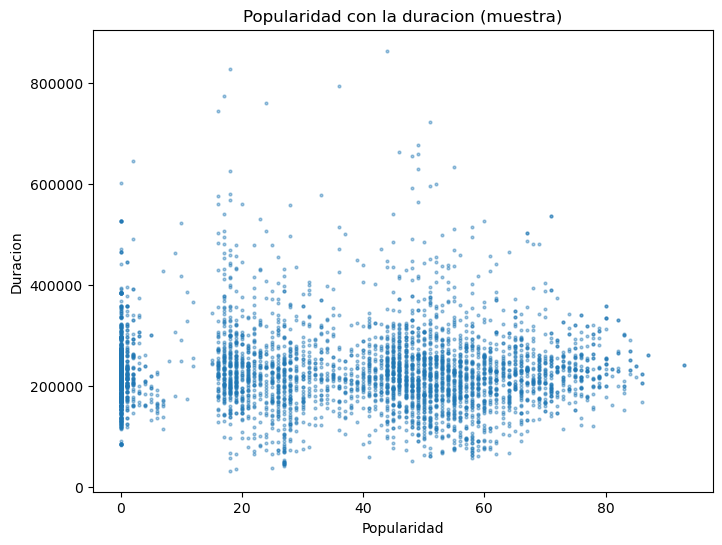

In [92]:
plt.figure(figsize=(8, 6))
plt.scatter(datos['popularity'], datos['duration_ms'], s=4, alpha=0.4)
plt.xlabel('Popularidad')
plt.ylabel('Duracion')
plt.title('Popularidad con la duracion (muestra)')
plt.show()

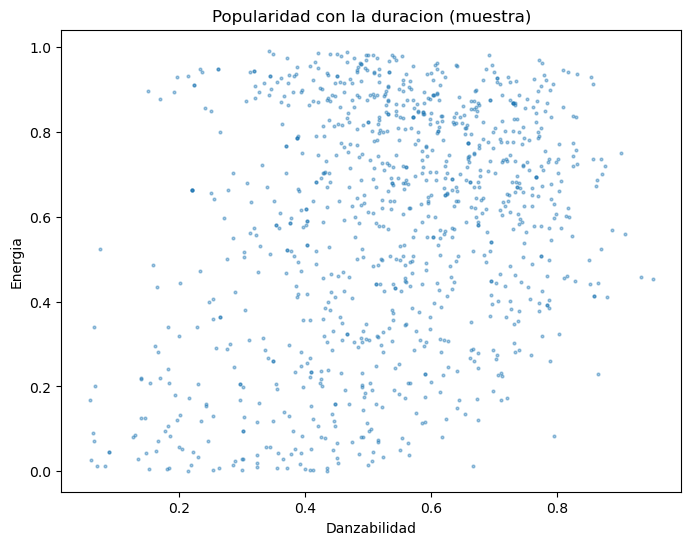

In [93]:
plt.figure(figsize=(8, 6))
plt.scatter(muestra['danceability'], muestra['energy'], s=4, alpha=0.4)
plt.xlabel('Danzabilidad')
plt.ylabel('Energia')
plt.title('Popularidad con la duracion (muestra)')
plt.show()


**Responde aquí:**

¿Qué variables has descartado y por qué? ¿Qué variables usarás para el clustering?

*Tu respuesta:*
- He descartado todas las que son categoricas, porque no nos aportan nada, ya que en una misma columnas hay muchas opciones. Tambien he descartado las dos que aportan ID, ya que por defecto no nos aportan nada, hay un id diferente por dato.
- De primeras pense en: popularity y duration_ms, ya que enfocado a el dataset que tenemos viendo la popularidad y la duracion que es lo que mas se suele fijar la gente en cuanto a musica. Pero despues vi que necesitaba variables parecidas entre si, como por ejemplo; danceability y energy. 

---
## Parte 2 · Preprocesamiento

Efectúa las tareas que ayudan al preprocesamiento de los datos justificando su necesidad.

In [94]:
# Tu Código
# Escalado de los datos, necesario ya que estamos trabajando con distancias.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(muestra)

print('Primeras filas escaladas:')
print(X_scaled[:5])

Primeras filas escaladas:
[[-0.81649319 -1.04786653]
 [-1.21585009 -2.00831823]
 [-1.79777016 -1.88276435]
 [-0.13188134  0.72549333]
 [ 1.32862392  0.25732633]]


**Responde aquí:**
Se necesita hacer escalado de los datos ya que estamos trabajando con distancias, y datos como la popularidad que puede ir en un rango de 0-100 y despues el tiempo que puede ser mucho mayor (+2000ms), si no escalamos, predominaria siempre la variable que mayor tamaño tenga.

---
## Parte 3 · Algoritmo K-Means

Aplica el Método del Codo para determinar el valor óptimo de K. Entrena K-Means y visualiza los clusters.

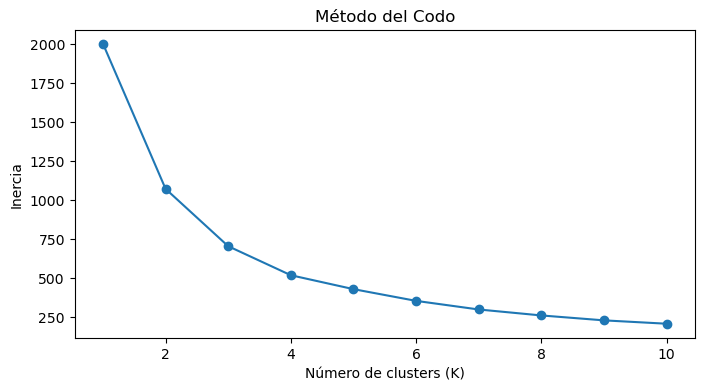

In [95]:
# Tu Código
inercia = []
i = 2
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # X_scaled es el dataset normalizado
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()

In [96]:
clusters = kmeans.labels_

In [97]:
labels = kmeans.labels_
centroides = kmeans.cluster_centers_
print("Primeros clusters asignados:", clusters[:20])
print("\nCentroides:")
print(kmeans.cluster_centers_)

Primeros clusters asignados: [1 1 3 0 4 4 2 5 7 9 2 7 7 0 7 1 5 5 9 0]

Centroides:
[[-2.62098339e-02  1.05373433e+00]
 [-5.69041734e-01 -1.58611886e+00]
 [-9.78961318e-02 -6.61083397e-01]
 [-1.93154332e+00 -1.51663080e+00]
 [ 1.40699699e+00  1.15565014e-01]
 [-1.04446268e+00  1.10640131e+00]
 [ 9.12464325e-01 -9.90846937e-01]
 [-1.05076794e+00 -2.20090328e-04]
 [ 1.02661882e+00  9.26549776e-01]
 [ 2.99967885e-01  2.43277991e-01]]


In [98]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
clusters = kmeans.labels_

In [99]:
muestra['cluster'] = clusters
muestra.head()

,danceability,energy,cluster
198,0.394,0.2810,2
4276,0.324,0.0102,2
4325,0.222,0.0456,2
3135,0.514,0.7810,0
3582,0.770,0.6490,1


In [100]:
muestra["cluster"].unique()

array([2, 0, 1], dtype=int32)

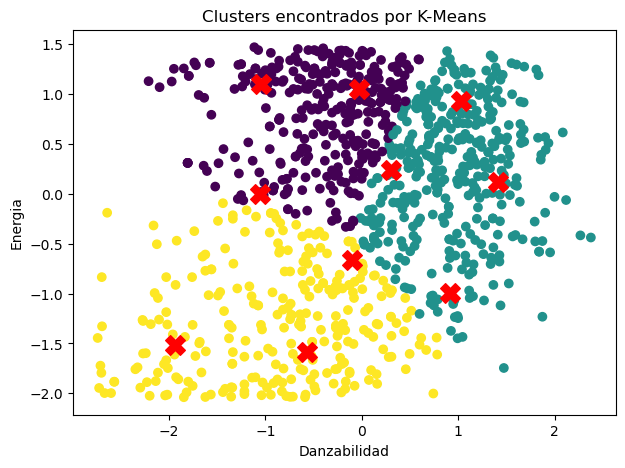

In [105]:
plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    marker='X',
    s=200,
    color='red'
)
plt.xlabel("Danzabilidad")
plt.ylabel("Energia")
plt.title("Clusters encontrados por K-Means")
plt.show()

**Responde aquí:**

Describe cada cluster en términos musicales. ¿Qué tipo de canción representa cada grupo? ¿Qué nombre le pondrías?

*Tu respuesta:*

## PArte 4 · Algoritmo DBSCAN
Utiliza el gráfico de distancias al vecino más cercano (k-distance graph) para estimar ε. Justifica el valor de min_samples. Visualiza los clusters identificando los puntos de ruido e interpreta su relación con los outliers detectados en el preprocesamiento.

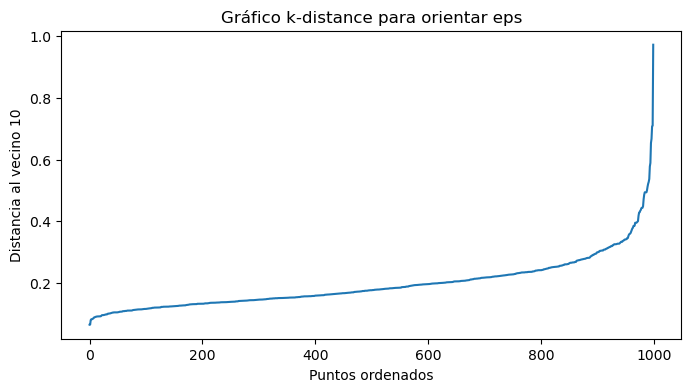

In [106]:
# Tu Código


min_samples = 10
vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos.fit(X_scaled)

distancias, indices = vecinos.kneighbors(X_scaled)

distancias_ordenadas = np.sort(distancias[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distancias_ordenadas)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {min_samples}')
plt.title('Gráfico k-distance para orientar eps')
plt.show()

In [115]:
modelo = DBSCAN(eps=0.08, min_samples=10)
clusters = modelo.fit_predict(X_scaled)

muestra['cluster'] = clusters
muestra.head()

,danceability,energy,cluster
198,0.394,0.2810,-1
4276,0.324,0.0102,-1
4325,0.222,0.0456,-1
3135,0.514,0.7810,-1
3582,0.770,0.6490,-1


In [116]:
muestra["cluster"].unique()

array([-1,  0,  1])

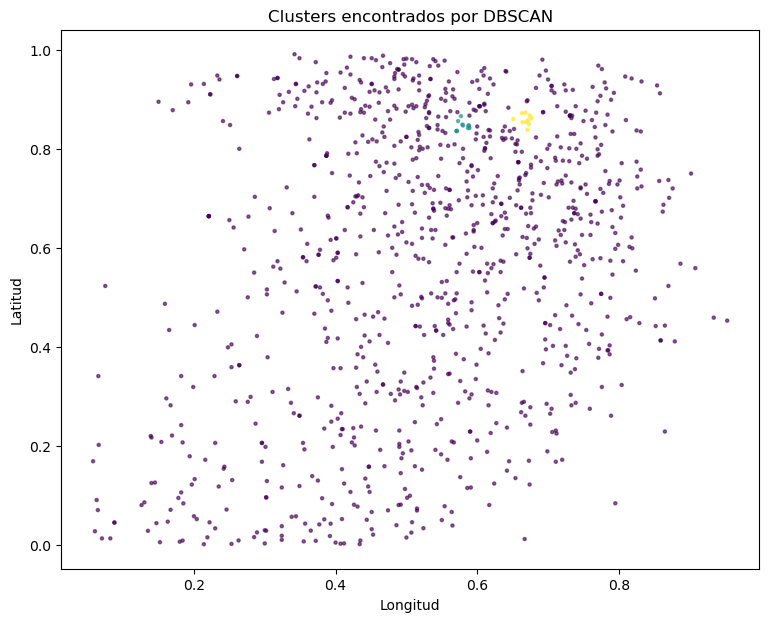

In [119]:
plt.figure(figsize=(9, 7))
plt.scatter(
    muestra['danceability'],
    muestra['energy'],
    c=muestra['cluster'],
    s=5,
    alpha=0.6
)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Clusters encontrados por DBSCAN')
plt.show()

In [ ]:
#danceability, energy

**Responde aquí:**

*Tu respuesta:*
EL valor de min_samples es 10, ya que es el numero de puntos para que sean clusters, me parece razonable por los datos que tenemos.

---
## Parte 5 · Comparación entre K-Means y DBSCAN

Esta sección es la más importante de la prueba. Se evalúa tu capacidad para razonar sobre los algoritmos, no solo para aplicarlos.

**Pregunta 5.1**  
¿Los dos algoritmos han producido segmentaciones similares o diferentes? Compara los resultados visualmente.

*Tu respuesta:* Se han producido segmentaciones parecidas. EN las dos visualizaciones que indico mas arriba se puede llegar a ver.
En los dos casos se llegan a sacar 3 clusters.

**Pregunta 5.2**  
¿Cuál de los dos algoritmos consideras más adecuado para segmentar canciones? Justifica tu respuesta.

*Tu respuesta:* Me parece mas correwcto DBSCAN, ya que cada persona es diferente y puede haber diferentes outliers, que es algo que k-means no puede trabajar con ello, para identificacion y trabajo con outliers siempre es mejor dbscan.

**Pregunta 5.3**  
Los outliers del dataset, ¿cómo los ha tratado cada algoritmo? ¿Cuál de los dos comportamientos es más deseable en este caso?

*Tu respuesta:* K-Means los outliers les ha incluido en un cluster. DBSCAN los identifica y no los trata ni los intenta incluir en ningun cluster. En este caso es mas deseable DBSCAN, debido a eso mismo, a que existen outliers y se deben de tratar, pasando de ellos.

**Pregunta 5.4**  
¿Cuál de los dos algoritmos es más sensible a la elección de sus hiperparámetros? ¿Por qué?

*Tu respuesta:* Es mas sensible DBSCAN debido a que si se elige un mal epsion puede cometer fallos como desagrupar y tratar como ouliers datos que no son.

---
## Parte 6 · Cuestiones

**Pregunta 6.1**  
¿Cómo sabes si el clustering ha funcionado bien sin disponer de etiquetas reales? ¿Qué métricas o criterios usarías?

*Tu respuesta:* Observando que se vea claramente la distincion entre diferentes grupos y la agrupacion de los grupos similares /parecidos.

**Pregunta 6.2**  
Este dataset tiene variables como `track_genre`. ¿Cambiaría esto el tipo de problema? ¿Usarías el mismo enfoque o uno diferente?

*Tu respuesta:* Creo que si lo cambiaria, se podria llegar a convertir a numerica y tratar con ella, ya que son categorias de la musica, varias y cada una diferente, por las cuales una persona u otra le suele gustar una, otra o varias. Usuaria principalmente esa variable junto con alguna otra.